# LAB-03 - Regresión Logística
## Nombre: Huarachi Clemente Ariel
## Carrera: Ing. de Sistemas
## C.U. 35-5544


# **PREPARAMOS EL DATASET**

In [105]:
# Nos conectamos a nuestro drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
# utilizando la libreria os para manejos de directorios
import os

# Computacion vectorial y cientifica para python
import numpy as np

#importamos pandas para el manejo del dataset, y separarlos dentro de una matriz
import pandas as pd

#esta tabulate nos sirve para hacer tablas
from tabulate import tabulate

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # -> Necesario para graficar superficies 3D

#Para separa el 20% y 80%
from sklearn.model_selection import train_test_split

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [107]:
#Haciendo uso de la libreria pandas para leer el dataset.
data = pd.read_csv('/content/drive/MyDrive/SIS420-INTELIGENCIA ARTIFICIAL/DATASET/WA_Fn-UseC_-HR-Employee-Attrition.csv', delimiter=',')

#Imprimimos en una tabla el dataset.
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [108]:

# === INFORMACIÓN DE TIPO DE DATOS
print('INFORMACION DE TIPO DE DATOS')
data.info()

# === FALTANTES POR COLUMNA (conteo) ===
print('\nDATOS VACIOS')
print(data.isna().sum())


INFORMACION DE TIPO DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 


In [109]:
# Partimos de tu DataFrame actual (data)
cols_a_descartar = [c for c in ['EmployeeCount','Over18','StandardHours','EmployeeNumber'] if c in data.columns]

print("Columnas a descartar:", cols_a_descartar)
data = data.drop(columns=cols_a_descartar)

print("Shape después de descartar:", data.shape)

# Comprobación rápida del target
print("\nDistribución Attrition:")
print(data['Attrition'].value_counts())

# (Vista previa de qué queda categórico para el próximo paso)
cat_cols_restantes = data.select_dtypes(include='object').columns.tolist()
print("\nCategóricas que faltan codificar:", cat_cols_restantes)


Columnas a descartar: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Shape después de descartar: (1470, 31)

Distribución Attrition:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Categóricas que faltan codificar: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


mostrar tabla


In [110]:
import pandas as pd

# Asegúrate de estar partiendo de la versión de 31 columnas
# (la que ya tiene Attrition 0/1 y SIN EmployeeCount/Over18/StandardHours/EmployeeNumber)
df = data.copy()

cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

# Convertir a categoría y luego a códigos enteros 0..k-1
# Guardamos los mapeos por si luego quieres usarlos en datos nuevos
ord_maps = {}
for c in cat_cols:
    df[c] = df[c].astype('category')
    ord_maps[c] = {cat: code for code, cat in enumerate(df[c].cat.categories)}
    df[c] = df[c].cat.codes.astype(int)

print("Shape final (debería seguir en 1470 x 31):", df.shape)
print("Tipos restantes:", set(map(str, df.dtypes)))
df.head(10)


Shape final (debería seguir en 1470 x 31): (1470, 31)
Tipos restantes: {'object', 'int64'}


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,2,1102,2,1,2,1,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,1,279,1,8,1,1,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,2,1373,1,2,2,4,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,1,1392,1,3,4,1,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,2,591,1,2,1,3,1,Male,...,3,4,1,6,3,3,2,2,2,2
5,32,No,1,1005,1,2,2,1,4,Male,...,3,3,0,8,2,2,7,7,3,6
6,59,No,2,1324,1,3,3,3,3,Female,...,4,1,3,12,3,2,1,0,0,0
7,30,No,2,1358,1,24,1,1,4,Male,...,4,2,1,1,2,3,1,0,0,0
8,38,No,1,216,1,23,3,1,4,Male,...,4,2,0,10,2,3,9,7,1,8
9,36,No,2,1299,1,27,3,3,3,Male,...,3,2,2,17,3,2,7,7,7,7


In [111]:
data.shape

(1470, 31)

In [112]:
import numpy as np
import pandas as pd

# 0) Copia de trabajo
df = data.copy()

# 1) Mapea binarios texto -> 0/1 (si ya están numéricos, no pasa nada)
if df['Attrition'].dtype == 'object':
    df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0}).astype('int64')

if 'Gender' in df.columns and df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0}).astype('int64')

# 2) Categóricas restantes -> códigos enteros 0..k-1
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'JobRole', 'MaritalStatus']

# (opcional) guarda los mapeos para reproducibilidad
ord_maps = {}
for c in cat_cols:
    df[c] = df[c].astype('category')
    ord_maps[c] = {cat: code for code, cat in enumerate(df[c].cat.categories)}
    df[c] = df[c].cat.codes.astype('int64')

# 3) Verificación: no deben quedar columnas object
print("Quedan object:", df.select_dtypes(include='object').columns.tolist())
print("Shape:", df.shape)
print(df.dtypes.value_counts())


Quedan object: ['OverTime']
Shape: (1470, 31)
int64     30
object     1
Name: count, dtype: int64


In [113]:
# Mapear OverTime a 0/1 (si está en texto)
if 'OverTime' in df.columns and df['OverTime'].dtype == 'object':
    print("Valores OverTime:", df['OverTime'].unique())

    # normaliza el texto y mapea
    df['OverTime'] = (
        df['OverTime'].astype(str).str.strip().str.lower()
          .map({'yes': 1, 'no': 0})
    )

    # verifica que no quedaron valores sin mapear
    assert not df['OverTime'].isna().any(), "OverTime tiene valores no mapeados (ni 'yes' ni 'no')"

    df['OverTime'] = df['OverTime'].astype('int64')

# chequeo final
print("Quedan object:", df.select_dtypes(include='object').columns.tolist())
print(df.dtypes.value_counts())
# Mapear OverTime a 0/1 (si está en texto)
if 'OverTime' in df.columns and df['OverTime'].dtype == 'object':
    print("Valores OverTime:", df['OverTime'].unique())

    # normaliza el texto y mapea
    df['OverTime'] = (
        df['OverTime'].astype(str).str.strip().str.lower()
          .map({'yes': 1, 'no': 0})
    )

    # verifica que no quedaron valores sin mapear
    assert not df['OverTime'].isna().any(), "OverTime tiene valores no mapeados (ni 'yes' ni 'no')"

    df['OverTime'] = df['OverTime'].astype('int64')

# chequeo final
print("Quedan object:", df.select_dtypes(include='object').columns.tolist())
print(df.dtypes.value_counts())


Valores OverTime: ['Yes' 'No']
Quedan object: []
int64    31
Name: count, dtype: int64
Quedan object: []
int64    31
Name: count, dtype: int64


In [114]:
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# ✅ Usaremos df (1470 x 31) con Attrition=0/1
assert 'Attrition' in df.columns, "Falta la columna 'Attrition' en df"

# Índice de la columna objetivo (para usar iloc al estilo que te gusta)
idx_y = df.columns.get_loc('Attrition')

# Split 80/20 estratificado (mantiene la proporción de clases)
train_data, test_data = train_test_split(
    df, test_size=0.20, random_state=42, stratify=df['Attrition']
)

# ---- Estilo con ILOC (como tu ejemplo), pero robusto ----
# X = todas las columnas excepto Attrition; y = Attrition
all_idx = list(range(df.shape[1]))
x_idx = [i for i in all_idx if i != idx_y]

X_test  = test_data.iloc[:, x_idx]
y_test  = test_data.iloc[:, idx_y]

X_train = train_data.iloc[:, x_idx]
y_train = train_data.iloc[:, idx_y]

m = y_train.size

# Mostramos los datos que serán para el entrenamiento (tu mismo estilo)
print("Datos de X_train:")
print(X_train)
print('-' * 100)
print("Datos de y_train:")
print(y_train)

# Cantidades 80/20
print('-' * 80)
print("El 80% de ejemplos que serán para el entrenamiento son: {:.0f}".format(len(train_data)))
print("El 20% de ejemplos que serán para el test son: {:.0f}".format(len(test_data)))

# (Opcional) Proporción de la clase positiva para verificar el estratificado
print("\nProporción Attrition=1 -> Train: {:.3f} | Test: {:.3f}"
      .format(y_train.mean(), y_test.mean()))
print("Conteos Train -> 0:", (y_train==0).sum(), " | 1:", (y_train==1).sum())
print("Conteos Test  -> 0:", (y_test==0).sum(),  " | 1:", (y_test==1).sum())


Datos de X_train:
      Age  BusinessTravel  DailyRate  Department  DistanceFromHome  Education  \
1194   47               2       1225           2                 2          4   
128    22               2        594           1                 2          1   
810    46               2        406           2                 3          1   
478    25               2        622           2                13          1   
491    43               1       1001           1                 9          5   
...   ...             ...        ...         ...               ...        ...   
1213   23               2        427           2                 7          3   
963    38               2       1009           2                 2          2   
734    22               2        217           1                 8          1   
1315   36               2        430           1                 2          4   
1292   39               1        766           2                20          3   

      Edu

In [115]:
def plotData(X, y):
    # Gragica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, 0], X[pos, 1], 'k*', lw=2, ms=10)
    pyplot.plot(X[neg, 0], X[neg, 1], 'ko', mfc='y', ms=8, mec='k', mew=1)


In [116]:
# Elegimos dos variables reales de tu dataset (cámbialas si quieres)
col_x = 'MonthlyIncome'
col_y = 'Age'

# Posición (índice) de esas columnas dentro de X_train
pos_x = X_train.columns.get_loc(col_x)
pos_y = X_train.columns.get_loc(col_y)

print(f"'{col_x}' está en la posición {pos_x} en X_train")
print(f"'{col_y}' está en la posición {pos_y} en X_train")


'MonthlyIncome' está en la posición 15 en X_train
'Age' está en la posición 0 en X_train


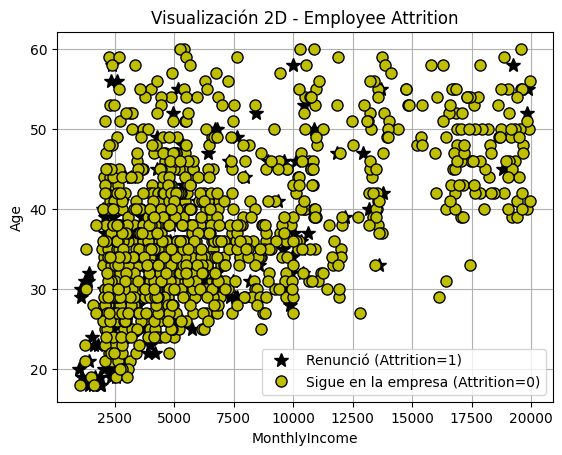

In [117]:
from matplotlib import pyplot

# Construimos la matriz que espera tu plotData (m, 2)
X_plot = X_train.iloc[:, [pos_x, pos_y]].values
y_plot = y_train.values  # 0 = sigue, 1 = renunció

# Llamamos a TU función (no la cambiamos)
plotData(X_plot, y_plot)

# Etiquetas y leyenda adaptadas a tu caso
pyplot.xlabel(col_x)
pyplot.ylabel(col_y)
pyplot.legend(['Renunció (Attrition=1)', 'Sigue en la empresa (Attrition=0)'])
pyplot.title('Visualización 2D - Employee Attrition')
pyplot.grid(True)
pyplot.show()
pass


Normalización de los datos:

In [118]:
# Defenimos la funcion de normalizacion de datos
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)

    sigma[sigma == 0] = 1  # verificar

    #normalizamos los datos con la siguiente formula
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [119]:
# Llamamos a la funcion de normalización para normalizar los datos de X_train
X_norm, mu, sigma = featureNormalize(X_train)

In [120]:
X_norm

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1194,1.090194,0.597520,1.049455,1.386635,-0.899915,1.064209,-0.938410,-0.658710,-1.221280,-0.908436,...,-0.432065,0.240218,2.613100,2.261482,-0.605389,0.337621,-0.665706,-0.625365,-0.368024,-0.616406
128,-1.634828,0.597520,-0.523449,-0.509508,-0.899915,-1.855332,2.032170,0.260202,0.818813,1.694111,...,-0.432065,0.240218,0.247430,-1.072675,-0.605389,0.337621,-0.830071,-0.905635,-0.056884,-0.897047
810,0.981193,0.597520,-0.992080,1.386635,-0.777610,-1.855332,-0.195765,-1.577622,0.818813,-0.662913,...,-0.432065,1.160403,0.247430,1.492061,0.190962,0.337621,0.813578,1.336527,0.565398,1.348076
478,-1.307825,0.597520,-0.453653,1.386635,0.445433,-1.855332,0.546880,-0.658710,0.818813,-1.252169,...,-0.432065,0.240218,-0.935405,-0.559727,-1.401740,0.337621,-0.008246,-0.064824,-0.679165,0.506155
491,0.654191,-0.894377,0.491086,-0.509508,-0.043784,2.037390,0.546880,1.179114,0.818813,0.319180,...,-0.432065,-0.679966,0.247430,-0.175017,0.190962,0.337621,0.156119,0.775986,0.565398,0.786795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1213,-1.525827,0.597520,-0.939733,1.386635,-0.288393,0.091029,-0.938410,0.260202,0.818813,1.645007,...,2.314467,-0.679966,0.247430,-1.072675,-0.605389,0.337621,-0.665706,-0.625365,-0.679165,-0.616406
963,0.109186,0.597520,0.511028,1.386635,-0.899915,-0.882152,-0.938410,-0.658710,-1.221280,-1.694111,...,-0.432065,1.160403,0.247430,-0.046780,0.190962,0.337621,-0.008246,0.775986,-0.368024,0.786795
734,-1.634828,0.597520,-1.463203,-0.509508,-0.166088,-1.855332,-0.938410,-0.658710,0.818813,1.399483,...,-0.432065,-1.600151,0.247430,-0.944438,0.190962,-1.055510,-0.501341,-0.345095,-0.368024,-0.897047
1315,-0.108815,0.597520,-0.932255,-0.509508,-0.899915,1.064209,1.289525,1.179114,-1.221280,0.368285,...,2.314467,1.160403,0.247430,0.466167,-0.605389,0.337621,-0.994436,-1.185905,-0.679165,-1.177687


In [121]:
# Obtener las dimensiones del array
m, n = X_train.shape

print(f"m (número de filas): {m}")
print(f"n (número de columnas): {n}")

m (número de filas): 1176
n (número de columnas): 30


Agregamos una columna de unos

In [122]:
X_ready = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [123]:
mu

,0
Age,36.998299
BusinessTravel,1.599490
DailyRate,803.991497
Department,1.268707
DistanceFromHome,9.357993
Education,2.906463
EducationField,2.263605
EnvironmentSatisfaction,2.716837
Gender,0.598639
HourlyRate,65.500000


In [124]:
sigma

,0
Age,9.174239
BusinessTravel,0.670288
DailyRate,401.168749
Department,0.527386
DistanceFromHome,8.176325
Education,1.027559
EducationField,1.346538
EnvironmentSatisfaction,1.088244
Gender,0.490174
HourlyRate,20.364660


In [125]:
X_ready

array([[ 1.        ,  1.09019402,  0.59751994, ..., -0.62536487,
        -0.36802436, -0.6164065 ],
       [ 1.        , -1.6348276 ,  0.59751994, ..., -0.9056351 ,
        -0.05688371, -0.89704685],
       [ 1.        ,  0.98119316,  0.59751994, ...,  1.33652675,
         0.5653976 ,  1.348076  ],
       ...,
       [ 1.        , -1.6348276 ,  0.59751994, ..., -0.34509464,
        -0.36802436, -0.89704685],
       [ 1.        , -0.10881549,  0.59751994, ..., -1.18590534,
        -0.67916501, -1.17768721],
       [ 1.        ,  0.21818711, -0.89437699, ..., -0.9056351 ,
        -0.05688371, -0.6164065 ]])

FUNCIÓN SIGMOIDEA

In [126]:
def calcularSigmoide(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [127]:
print(calcularSigmoide(0))

0.5


In [128]:
# Prueba la implementación de la funcion sigmoidea
z = [0, 0.5, 1]
g = calcularSigmoide(z)

print('g(', z, ') = ', g)

g( [0, 0.5, 1] ) =  [0.5        0.62245933 0.73105858]


Función de Costo y Gradiente

Se implementa la funcion cost y gradient, para la regresión logistica. Antes de continuar es importante agregar el termino de intercepcion a X.

In [129]:
# después de definir calcularSigmoide(z)
def sigmoid(z):
    return calcularSigmoide(z)


In [130]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [131]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [132]:
from matplotlib import pyplot

In [133]:
# X_ready ya lo tienes como [1 | X_norm] de tamaño (m, n)
Xg = X_ready.astype(float)
yg = y_train.values.astype(float).ravel()

theta = np.zeros(Xg.shape[1], dtype=float)   # ¡no X_train.shape[1]!
alpha = 0.001
num_iters = 60000


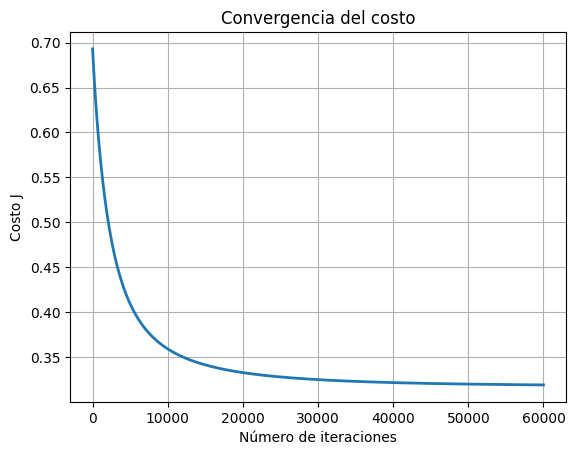

θ calculado por descenso de gradiente (dim=31):
[-2.26808051 -0.39622823 -0.02438452 -0.17703758  0.35942669  0.2906525
  0.02435057 -0.05449408 -0.40267854  0.13126262] ...


In [134]:
theta, J_history = descensoGradiente(theta, Xg, yg, alpha, num_iters)

import matplotlib.pyplot as pyplot
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.grid(True)
pyplot.show()

print('θ calculado por descenso de gradiente (dim={}):'.format(theta.shape[0]))
print(theta[:10], '...')


In [135]:
print(f"Con un costo de: { J_history[-1]} ")

Con un costo de: 0.3191595524387147 


In [136]:
print("X_ready shape:", Xg.shape)  # (m, n)
print("y shape:", yg.shape)        # (m,)
print("theta shape:", theta.shape)  # (n,)


X_ready shape: (1176, 31)
y shape: (1176,)
theta shape: (31,)


# Predicción y validación del modelo


In [137]:
import numpy as np
# si X_norm es DataFrame:
print(" |mean| promedio:", np.abs(X_norm.mean()).mean())
print(" std  promedio:", X_norm.std(ddof=0).mean())


 |mean| promedio: 8.97744967304605e-17
 std  promedio: 1.0000000000000002


In [138]:
# Normalizamos el X_test
X_test_norm = (X_test - mu) / sigma
m_test = len(X_test)

X_test_norm

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,HourlyRate,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1061,-1.416826,-2.386274,0.064832,1.386635,0.445433,-0.882152,-0.938410,1.179114,-1.221280,0.613808,...,-0.432065,0.240218,0.247430,-1.329148,-0.605389,0.337621,-0.994436,-1.185905,-0.679165,-1.177687
891,0.763191,0.597520,0.780241,-0.509508,-0.899915,-1.855332,-0.938410,-1.577622,-1.221280,0.319180,...,-0.432065,1.160403,0.247430,-0.175017,1.783664,0.337621,0.484849,0.215446,1.498820,0.786795
456,-0.653820,0.597520,-0.289134,1.386635,-0.288393,0.091029,-0.938410,0.260202,0.818813,-1.055750,...,2.314467,0.240218,0.247430,-0.175017,0.190962,-1.055510,-0.336976,-0.064824,-0.679165,-0.897047
922,0.763191,0.597520,0.984644,-0.509508,-0.655306,-0.882152,-0.938410,0.260202,0.818813,1.301274,...,-0.432065,1.160403,1.430265,1.876772,0.987313,-1.055510,2.950322,1.336527,3.676804,2.470637
69,-0.108815,0.597520,-1.211439,-0.509508,-0.043784,0.091029,0.546880,1.179114,0.818813,0.662913,...,-0.432065,-1.600151,0.247430,-1.200911,-2.198092,-1.055510,-0.994436,-1.185905,-0.679165,-1.177687
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,0.654191,0.597520,-1.395900,-2.405651,-0.899915,0.091029,-0.938410,-0.658710,0.818813,1.546797,...,-0.432065,-0.679966,-0.935405,-0.175017,1.783664,0.337621,0.320484,0.775986,-0.368024,1.067436
1352,0.763191,0.597520,-1.580361,-0.509508,-1.022219,1.064209,-0.938410,-0.658710,0.818813,0.613808,...,-0.432065,1.160403,0.247430,-0.175017,1.783664,0.337621,-0.830071,-1.185905,-0.056884,-0.616406
1236,-0.108815,0.597520,1.625272,1.386635,0.445433,2.037390,-0.195765,-0.658710,0.818813,1.497693,...,-0.432065,-0.679966,2.613100,0.594404,0.190962,0.337621,-0.830071,-0.625365,-0.056884,-0.616406
1023,2.071202,0.597520,1.124236,-0.509508,-1.022219,-0.882152,-0.938410,-1.577622,-1.221280,1.203065,...,2.314467,1.160403,0.247430,-0.816201,0.190962,1.730752,-0.665706,-0.625365,-0.368024,-1.177687


In [139]:
X_test_ready = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)
print(X_test_ready)

[[ 1.00000000e+00 -1.41682587e+00 -2.38627392e+00 ... -1.18590534e+00
  -6.79165010e-01 -1.17768721e+00]
 [ 1.00000000e+00  7.63191429e-01  5.97519945e-01 ...  2.15445825e-01
   1.49881955e+00  7.86795286e-01]
 [ 1.00000000e+00 -6.53819813e-01  5.97519945e-01 ... -6.48244074e-02
  -6.79165010e-01 -8.97046855e-01]
 ...
 [ 1.00000000e+00 -1.08815489e-01  5.97519945e-01 ... -6.25364871e-01
  -5.68837075e-02 -6.16406498e-01]
 [ 1.00000000e+00  2.07120181e+00  5.97519945e-01 ... -6.25364871e-01
  -3.68024359e-01 -1.17768721e+00]
 [ 1.00000000e+00  1.85375620e-04  5.97519945e-01 ...  2.17733745e+00
   8.76538246e-01  7.86795286e-01]]


In [140]:
# Probabilidades de attrition (renuncia) en TEST — vectorizado
y_proba = calcularSigmoide(X_test_ready @ theta)      # shape (m_test,)

# (si quieres conservar el nombre que usabas)
y_predicha = y_proba

# Umbral (puedes moverlo si quieres)
umbral = 0.5
y_pred = (y_proba >= umbral).astype(int)              # 1=Renuncia, 0=Sigue

# DataFrame prolijo con % y etiquetas
df_pred = pd.DataFrame({
    "Prob_Attrition": y_proba,
    "Prob_Attrition_%": (y_proba * 100).round(2),
    "Pred_Attrition": y_pred,
    "Attrition_real": y_test.values
}, index=y_test.index)

df_pred["Pred_label"] = df_pred["Pred_Attrition"].map({1:"Renuncia", 0:"Sigue"})
df_pred["Real_label"] = df_pred["Attrition_real"].map({1:"Renuncia", 0:"Sigue"})

# Muestra rápida
df_pred.head(15)


,Prob_Attrition,Prob_Attrition_%,Pred_Attrition,Attrition_real,Pred_label,Real_label
1061,0.170603,17.06,0,0,Sigue,Sigue
891,0.011147,1.11,0,0,Sigue,Sigue
456,0.193975,19.40,0,0,Sigue,Sigue
922,0.003111,0.31,0,0,Sigue,Sigue
69,0.492861,49.29,0,1,Sigue,Renuncia
1164,0.318995,31.90,0,0,Sigue,Sigue
406,0.037448,3.74,0,0,Sigue,Sigue
1330,0.016862,1.69,0,0,Sigue,Sigue
1232,0.016314,1.63,0,0,Sigue,Sigue
1311,0.368675,36.87,0,0,Sigue,Sigue


In [141]:
df_pred = pd.DataFrame((y_proba * 100).round(2), columns=["Probabilidad de renuncia %"])


In [142]:
# 1) (por si acaso) calcula las probabilidades primero
y_proba = calcularSigmoide(X_test_ready @ theta)   # vector de tamaño m_test

# 2) crea el DataFrame en %
df_pred = pd.DataFrame(
    {"Probabilidad de renuncia %": (y_proba * 100).round(2)},
    index=y_test.index
)

# 3) muéstralo
from IPython.display import display
display(df_pred.head(20))   # o simplemente: df_pred


,Probabilidad de renuncia %
1061,17.06
891,1.11
456,19.40
922,0.31
69,49.29
1164,31.90
406,3.74
1330,1.69
1232,1.63
1311,36.87


In [143]:
y_umbral = (y_predicha >= 0.5).astype(int)

In [144]:
# Mostramos la precisión de entrenamiento
proba_train   = calcularSigmoide(X_ready @ theta)          # probs en train
y_pred_train  = (proba_train >= 0.5).astype(int)           # 0/1 con umbral 0.5
acc_train     = (y_pred_train == y_train.values).mean()    # exactitud

print(f"Precisión de entrenamiento: {acc_train*100:.2f}%")


Precisión de entrenamiento: 87.41%


In [145]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import numpy as np

# ===== TRAIN =====
proba_train  = calcularSigmoide(X_ready @ theta)
y_pred_train = (proba_train >= 0.5).astype(int)
acc_train    = accuracy_score(y_train, y_pred_train)

print("=== TRAIN ===")
print(f"Accuracy: {acc_train*100:.2f}%")
print(confusion_matrix(y_train, y_pred_train))
print(classification_report(y_train, y_pred_train, digits=3))

# ===== TEST =====
proba_test  = calcularSigmoide(X_test_ready @ theta)   # ya lo tienes como y_proba
y_pred_test = (proba_test >= 0.5).astype(int)
acc_test    = accuracy_score(y_test, y_pred_test)

print("\n=== TEST ===")
print(f"Accuracy: {acc_test*100:.2f}%")
print("ROC-AUC:", roc_auc_score(y_test, proba_test).round(4))
print(confusion_matrix(y_test, y_pred_test))
print(classification_report(y_test, y_pred_test, digits=3))


=== TRAIN ===
Accuracy: 87.41%
[[963  23]
 [125  65]]
              precision    recall  f1-score   support

           0      0.885     0.977     0.929       986
           1      0.739     0.342     0.468       190

    accuracy                          0.874      1176
   macro avg      0.812     0.659     0.698      1176
weighted avg      0.861     0.874     0.854      1176


=== TEST ===
Accuracy: 88.10%
ROC-AUC: 0.806
[[241   6]
 [ 29  18]]
              precision    recall  f1-score   support

           0      0.893     0.976     0.932       247
           1      0.750     0.383     0.507        47

    accuracy                          0.881       294
   macro avg      0.821     0.679     0.720       294
weighted avg      0.870     0.881     0.864       294




* *Employee Attrition* (Kaggle), **1470** registros.
* Tras limpieza quedaron **31** variables totalmente numéricas (sin NA); se removieron columnas constantes/ID y se codificaron las categóricas; **Attrition** se binarizó (1=Renuncia, 0=Sigue).
* El conjunto está **desbalanceado**: \~**16%** renuncias vs 84% permanencias.

**Sobre el modelo y desempeño**

* Se entrenó **Regresión Logística** desde cero con normalización (μ/σ del train). La función de costo convergió (\~0.319).
* Generaliza bien: **Accuracy** 87.41% (train) vs **88.10%** (test), sin señales fuertes de sobreajuste.

Interpretación

* El modelo es **conservador**: cuando predice renuncia suele acertar (precisión alta), pero deja escapar varias renuncias.
* Si el objetivo es **no perder renuncias**, conviene:

  * **Bajar el umbral** de 0.5 para aumentar el recall (evaluar trade-off con precisión).
  
  con un dataset limpio y desbalanceado, la logística logra **AUC 0.806** y **\~88%** de exactitud; es útil para confirmar permanencias.
